In [ ]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# Run this cell first every time you open a new Colab session.
# Clones the repo (data and artifacts included) and configures the environment.
import os, sys

REPO_URL  = "https://github.com/tackes/Modern-Time-Series-Forecasting-Cohort.git"
REPO_PATH = "/content/packt-modern-time-series"

if not os.path.exists(REPO_PATH):
    os.system(f"git clone -q {REPO_URL} {REPO_PATH}")

# Stay in instructor_notebooks so Path().resolve().parent resolves to repo root
os.chdir(f"{REPO_PATH}/instructor_notebooks")

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

os.system("pip install -q lightgbm mlforecast")

print(f"✓ Setup complete — {os.getcwd()}")

# Module 5 — ML Forecasting with LightGBM
**Type:** [Code With Me]  
**Time:** 45 minutes  
**Job:** Prove that a feature-engineered ML pipeline beats the statistical baselines. Quantify the compute cost. Make an honest recommendation about whether the improvement justifies the infrastructure.

---

> **Instructor note:** This is the most technically dense module. Pace it in four blocks:
> - 5.1–5.3: Setup, panel load, feature framing (5 min)
> - 5.4–5.6: Configure MLForecast, define features, run CV (15 min, Code With Me)
> - 5.7–5.9: Conformal intervals, plot, score (12 min, Code With Me)
> - 5.10–5.12: Load full artifact, leaderboard update, enterprise cliff (8 min)
>
> The conformal interval construction in 5.8 is the hardest conceptual step. Budget 3 minutes for it.

---
## 5.1 — Setup
**[Watch Only]**

> **Instructor note (1 min):** Run silently. Note the new import: `MLForecast` and `LGBMRegressor`. Everything else is the same pattern as Modules 3 and 4.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams['figure.figsize'] = (14, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import lightgbm as lgb
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from mlforecast.utils import PredictionIntervals

from config import (
    ARTIFACT_DIR,
    PARAMS_DIR,
    HORIZON,
    SEASON_LENGTH,
    N_WINDOWS,
    STEP_SIZE,
    REFIT,
    MICRO_SUBSET_N,
    WORKSHOP_SUBSET_N,
    RANDOM_SEED,
    USE_TUNED_PARAMS,
    USE_INTERVALS,
)
from src.checkpointing import load_checkpoint
from src.evaluation import score_forecasts
from src.schemas import validate_forecast
from src.workshop_utils import get_micro_subset

print("Setup complete.")
print(f"USE_TUNED_PARAMS = {USE_TUNED_PARAMS}")
print(f"USE_INTERVALS    = {USE_INTERVALS}")

Setup complete.
USE_TUNED_PARAMS = True
USE_INTERVALS    = True


---
## 5.2 — Load Panel and Micro Subset
**[Watch Only]**

> **Instructor note (30 sec):** Same pattern as Module 4. Load from the validated artifact, select top-N by volume.

In [2]:
panel = load_checkpoint("03_validated_panel")
micro, top_series = get_micro_subset(panel, n=MICRO_SUBSET_N)

print(f"Micro panel: {micro['unique_id'].nunique()} series, {len(micro):,} rows")


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 03_validated_panel
    File     : 03_validated_panel.parquet
    Rows     : 1,941,000

Micro panel: 50 series, 97,050 rows


---
## 5.3 — Why ML Forecasting?
**[Watch Only]**

> **Instructor note (2 min):** Make the cost argument explicit before writing any code. This section answers the question students always have: "if AutoETS is good, why bother with LightGBM?"

AutoETS is a strong univariate model. It sees one series at a time. It cannot learn patterns that span series — shared seasonal profiles, cross-SKU promotional lifts, or price elasticity signals.

**LightGBM via MLForecast is a global model.** It trains on all series simultaneously. Each series becomes a set of training rows. The model learns patterns across the entire category portfolio.

**The compute tradeoff is real:**  
AutoETS on 1,000 series takes seconds. LightGBM on 1,000 series with lag features takes longer and produces a model artifact you now have to version, deploy, and monitor. The accuracy gain must justify that operational cost.

**The features we will build (baseline config — section 5.5):**

| Feature type | Examples | Business signal |
|---|---|---|
| Autoregressive lags | lag_7, lag_14, lag_28 | Recent demand history |
| Rolling mean | 28-day rolling mean on lag_7 | Trend smoothing |
| Date features | day_of_week, month | Calendar seasonality |

**Extended feature set (reference — section 5.5b):**

| Feature type | Examples | Business signal |
|---|---|---|
| Extended lags | lag_7, lag_14, lag_21, lag_28 | Demand echoes at 1–4 weeks |
| Rolling stats | mean, std, min, max, Q25, Q75 (28-day) | Level, volatility, range, distributional shape |
| Seasonal rolling | same-weekday mean over 4 and 8 weeks | Weekly demand profile, directly encoded |
| Fourier features | sin/cos terms for weekly and annual cycles | Circular seasonality without ordinal assumptions |

Adding lags in a notebook is a one-liner. Maintaining a feature store that recomputes these lags daily across 100,000 SKUs — with late data, backfills, and audit trails — is a data engineering project that takes months.

---
## 5.4 — Load LightGBM Parameters
**[Watch Only]**

> **Instructor note (1 min):** Load from `params/` based on the `USE_TUNED_PARAMS` toggle in config. The params files are pre-tested — do not change them live. Show students what is in the file.

In [3]:
params_file = "mlforecast_lgb_tuned.json" if USE_TUNED_PARAMS else "mlforecast_lgb_default.json"
params_path = PARAMS_DIR / params_file

with open(params_path) as f:
    lgb_params = json.load(f)

# Always lock the random seed from config — do not let params file override it
lgb_params["random_state"] = RANDOM_SEED

print(f"Loading params from: {params_file}")
for k, v in lgb_params.items():
    print(f"  {k:<22}: {v}")

Loading params from: mlforecast_lgb_tuned.json
  _comment              : AutoMLForecast Optuna-tuned params (default objective).
  n_estimators          : 675
  learning_rate         : 0.026585908882109703
  num_leaves            : 95
  min_child_samples     : 35
  subsample             : 0.8323930520817325
  colsample_bytree      : 0.9088540087875863
  reg_alpha             : 0.006250391643347274
  reg_lambda            : 0.011262001072312433
  random_state          : 42
  n_jobs                : -1
  verbosity             : -1


---
## 5.5 — Configure MLForecast
**[Code With Me — 3 lines]**

> **Instructor note (4 min):** This is the most important Code With Me cell in the module. Students fill in the `lags`, `lag_transforms`, and `date_features`. Walk through each argument:
> - `lags`: explicit integer list — `[7, 14, 28]`. These align to weekly, biweekly, and monthly demand patterns.
> - `lag_transforms`: rolling mean on lag 7, window 28 — smooths the weekly lag.
> - `date_features`: `dayofweek` and `month` — the two calendar signals that matter most for retail.
>
> Pause and check that everyone has the same config before running.

In [4]:
# Configure MLForecast — all feature engineering happens here, not in a separate step

mlf = MLForecast(
    models=[lgb.LGBMRegressor(**lgb_params)],
    freq="D",
    lags=[7, 14, 28],                               # __FILL_IN__: weekly, biweekly, monthly lags
    lag_transforms={
        7: [RollingMean(window_size=28)],            # __FILL_IN__: rolling mean on lag 7, window 28
    },
    date_features=["dayofweek", "month"],            # __FILL_IN__: day-of-week and month
)

print("MLForecast configured.")
print(f"  Lags          : {mlf.ts.lags}")
print(f"  Date features : {mlf.ts.date_features}")
print(f"  Model         : {next(iter(mlf.models.values())).__class__.__name__}")

MLForecast configured.
  Lags          : [7, 14, 28]
  Date features : ['dayofweek', 'month']
  Model         : LGBMRegressor


---
### 5.5b — Feature Engineering Reference: Richer Feature Sets
**[Watch Only]**

> **Instructor note (4 min):** This cell is a reference block — students do not fill anything in.
> Walk through each feature family and explain the intuition:
> - **More lags**: catch demand echoes at 1, 2, 3, 4 weeks + monthly
> - **Rolling statistics**: mean captures level, std captures volatility, min/max capture range, quantile captures distributional shape — all from the same lag window
> - **Fourier features**: encode seasonality as smooth sin/cos waves rather than integer labels. `dayofweek=3` gives the model no information about adjacency to days 2 and 4; `sin(2π·dow/7)` does. Two terms per period (k=1) is usually enough for weekly.
> - **Seasonal rolling mean**: average of the same weekday over the past N weeks — directly encodes the weekly pattern without relying on the model to discover it
>
> The baseline config in 5.5 is deliberately minimal. This block shows the full toolkit.
> Students copy what they need for their own datasets.

**Why Fourier over integer day-of-week?**
Integer labels (`dayofweek=3`) are ordinal — the model can learn a non-linear mapping, but only if it sees enough data.
Fourier features encode the circular structure of the week *in the input*, so the model needs fewer samples to learn the pattern.
On sparse series or short histories, Fourier features often outperform integer encoding.

A plain `dayofweek` column treats the days as numbers:

- Monday = 0
- Tuesday = 1
- ...
- Sunday = 6

That is convenient, but it hides the real structure. The week is **cyclical**, not linear. Sunday and Monday are next to each other in real life, but as integers they look far apart: `6` and `0`.

A model can eventually learn that pattern, but it has to discover it from the data.

Fourier features give the model that circular weekly structure upfront. They represent the week as smooth repeating sine/cosine waves, so the model can more easily learn patterns like:

- weekends behave differently from weekdays,
- demand rises into Friday,
- Monday resets after Sunday,
- weekly seasonality repeats.

So the practical reason is:

> Fourier features make weekly seasonality easier for the model to learn, especially when the history is short, sparse, or noisy.

In [5]:
# 5.5b — Feature Engineering Reference: Richer MLForecast Feature Sets
# This cell is a REFERENCE — swap the mlf definition in 5.5 to experiment.
# Each feature family is shown independently, then combined at the bottom.

import numpy as np
from mlforecast import MLForecast
from mlforecast.lag_transforms import (
    RollingMean,
    RollingStd,
    RollingMin,
    RollingMax,
    RollingQuantile,
    SeasonalRollingMean,
)

# ── 1. Lag list ───────────────────────────────────────────────────────────────
# Explicit lags: 1 week, 2 weeks, 3 weeks, 4 weeks, ~1 month
LAGS = [7, 14, 21, 28]

# ── 2. Rolling statistics on lag 7 ───────────────────────────────────────────
# window_size=4 weeks → statistics over a full month of same-weekday observations
# RollingQuantile(p=0.5) is the rolling median — robust to outlier demand spikes
ROLLING_28 = [
    RollingMean(window_size=28),
    RollingStd(window_size=28),
    RollingMin(window_size=28),
    RollingMax(window_size=28),
    RollingQuantile(p=0.25, window_size=28),  # lower quartile
    RollingQuantile(p=0.75, window_size=28),  # upper quartile
]

# ── 3. Seasonal rolling mean ──────────────────────────────────────────────────
# SeasonalRollingMean(season_length=7, window_size=4):
#   average of the same weekday over the past 4 weeks.
#   Directly encodes the weekly demand profile without the model needing to
#   discover it from raw lags.
SEASONAL_ROLLING = [
    SeasonalRollingMean(season_length=7, window_size=4),   # 4-week same-weekday mean
    SeasonalRollingMean(season_length=7, window_size=8),   # 8-week same-weekday mean
]

# ── 4. Fourier date features (via MLForecast date_features callables) ─────────
# MLForecast's date_features accepts any named callable that takes a
# pandas DatetimeIndex and returns a numeric array.
# Two Fourier terms per season (k=1) encode the weekly cycle as a smooth wave.
# k=2 adds a second harmonic — captures asymmetric within-week patterns.
#
# Why this instead of dayofweek integer?
# Integer encoding: model must learn non-linearity from data.
# Fourier encoding: circular structure is baked into the feature — fewer samples needed.

def fourier_sin1_weekly(dates):
    """First Fourier sine term for weekly seasonality (period=7)."""
    return np.sin(2 * np.pi * 1 * dates.dayofweek / 7)

def fourier_cos1_weekly(dates):
    """First Fourier cosine term for weekly seasonality (period=7)."""
    return np.cos(2 * np.pi * 1 * dates.dayofweek / 7)

def fourier_sin2_weekly(dates):
    """Second Fourier sine term — captures asymmetric weekly patterns."""
    return np.sin(2 * np.pi * 2 * dates.dayofweek / 7)

def fourier_cos2_weekly(dates):
    """Second Fourier cosine term — captures asymmetric weekly patterns."""
    return np.cos(2 * np.pi * 2 * dates.dayofweek / 7)

def fourier_sin1_annual(dates):
    """First Fourier sine term for annual seasonality (period=365.25)."""
    return np.sin(2 * np.pi * 1 * dates.dayofyear / 365.25)

def fourier_cos1_annual(dates):
    """First Fourier cosine term for annual seasonality (period=365.25)."""
    return np.cos(2 * np.pi * 1 * dates.dayofyear / 365.25)

DATE_FEATURES = [
    "month",
    fourier_sin1_weekly,
    fourier_cos1_weekly,
    fourier_sin2_weekly,
    fourier_cos2_weekly,
    fourier_sin1_annual,
    fourier_cos1_annual,
]

# ── 5. Full config ────────────────────────────────────────────────────────────
mlf_rich = MLForecast(
    models=[lgb.LGBMRegressor(**lgb_params)],
    freq="D",
    lags=LAGS,
    lag_transforms={
        7:  ROLLING_28 + SEASONAL_ROLLING,
        14: [RollingMean(window_size=28)],
    },
    date_features=DATE_FEATURES,
)

# Inspect the feature set without fitting
feature_names = mlf_rich.ts.transforms
print("Rich MLForecast feature set:")
print(f"  Lags                 : {LAGS}")
print(f"  Lag-7 transforms     : {len(ROLLING_28 + SEASONAL_ROLLING)} features")
print(f"    Rolling stats      : RollingMean, RollingStd, RollingMin, RollingMax, Q25, Q75")
print(f"    Seasonal rolling   : SeasonalRollingMean x2 (4-week, 8-week same-weekday)")
print(f"  Lag-14 transforms    : RollingMean(28)")
print(f"  Date features        : {len(DATE_FEATURES)} features")
print(f"    Calendar           : month")
print(f"    Fourier weekly k=2 : sin1, cos1, sin2, cos2")
print(f"    Fourier annual k=1 : sin1, cos1")
print()
print("To use this config for CV, replace `mlf` with `mlf_rich` in cell 5.6.")
print("Expected: +1-3 wMAPE improvement on datasets with strong weekly + annual seasonality.")

Rich MLForecast feature set:
  Lags                 : [7, 14, 21, 28]
  Lag-7 transforms     : 8 features
    Rolling stats      : RollingMean, RollingStd, RollingMin, RollingMax, Q25, Q75
    Seasonal rolling   : SeasonalRollingMean x2 (4-week, 8-week same-weekday)
  Lag-14 transforms    : RollingMean(28)
  Date features        : 7 features
    Calendar           : month
    Fourier weekly k=2 : sin1, cos1, sin2, cos2
    Fourier annual k=1 : sin1, cos1

To use this config for CV, replace `mlf` with `mlf_rich` in cell 5.6.
Expected: +1-3 wMAPE improvement on datasets with strong weekly + annual seasonality.


**Expected output:**
```
MLForecast configured.
  Lags          : [7, 14, 28]
  Date features : ['dayofweek', 'month']
  Model         : LGBMRegressor
```

---
## 5.6 — Run Cross-Validation on the Micro Subset
**[Watch Only]**

> **Instructor note (3 min):** Run and let it execute. LightGBM on 50 series with these features should complete in 15–25 seconds. While it runs, explain the recursive forecasting strategy: MLForecast feeds its own predictions back as lag inputs for each step in the horizon. This is why lag features create dependency chains.

In [6]:
%%time
# Cross-validation on micro subset
# Target runtime: < 30 seconds on Colab CPU
# PredictionIntervals requires refit=True — controlled via USE_INTERVALS in config.py

cv_ml_micro = mlf_rich.cross_validation(
    df=micro,
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=STEP_SIZE,
    refit=True if USE_INTERVALS else REFIT,                                                              # __FILL_IN__: True when using PredictionIntervals, REFIT otherwise
    prediction_intervals=PredictionIntervals(n_windows=N_WINDOWS, h=HORIZON) if USE_INTERVALS else None, # __FILL_IN__: Nixtla-native conformal intervals
    level=[80] if USE_INTERVALS else None,                                                               # __FILL_IN__: 80% prediction interval
)

print(f"ML CV complete. Shape: {cv_ml_micro.shape}")
print(f"Columns: {list(cv_ml_micro.columns)}")
print(cv_ml_micro.head(3).to_string())

ML CV complete. Shape: (4200, 7)
Columns: ['unique_id', 'ds', 'cutoff', 'y', 'LGBMRegressor', 'LGBMRegressor-lo-80', 'LGBMRegressor-hi-80']
          unique_id         ds     cutoff    y  LGBMRegressor  LGBMRegressor-lo-80  LGBMRegressor-hi-80
0  FOODS_2_360_WI_2 2016-02-29 2016-02-28  0.0       5.623603             1.824491             9.422715
1  FOODS_2_360_WI_2 2016-03-01 2016-02-28  0.0       5.757014             1.622279             9.891748
2  FOODS_2_360_WI_2 2016-03-02 2016-02-28  0.0       5.520811             1.365172             9.676450
CPU times: total: 7min 59s
Wall time: 17.2 s


**Expected output:**
```
ML CV complete. Shape: (4200, 7)
Columns: ['ds', 'cutoff', 'y', 'LGBMRegressor', 'LGBMRegressor-lo-80', 'LGBMRegressor-hi-80']
```

> **Instructor note:** MLForecast now returns interval columns directly — `LGBMRegressor-lo-80` and `LGBMRegressor-hi-80`. These are calibrated using held-out cross-validation windows via `PredictionIntervals`, not in-sample residuals. The reshape in 5.7 just renames these columns to the schema format.

---
## 5.7 — Reshape MLForecast CV Output
**[Code With Me — 2 lines]**

> **Instructor note (3 min):** MLForecast returns wide format with one column per model plus interval columns named `{model}-lo-80` and `{model}-hi-80`. The reshape function standardizes this to the forecast schema. Two fill-ins: rename the lo/hi columns to `lo_80` / `hi_80`.
>
> Key point to make: the intervals come from `PredictionIntervals` — MLForecast holds out additional CV windows internally to calibrate the conformal bounds. This is more statistically sound than computing percentiles of in-sample residuals, because calibration and evaluation use separate data.

In [7]:
# Reshape MLForecast wide output to forecast schema
def reshape_mlforecast_cv(cv_df: pd.DataFrame, model_col: str, stage: str) -> pd.DataFrame:
    """
    Reshape MLForecast wide CV output to forecast schema.
    Interval columns (lo_80, hi_80) come from PredictionIntervals — Nixtla-native conformal calibration.
    """
    df = cv_df.reset_index().copy()
    df = df.rename(columns={
        model_col:              "y_hat",
        f"{model_col}-lo-80":  "lo_80",   # __FILL_IN__: rename native lo column to schema name
        f"{model_col}-hi-80":  "hi_80",   # __FILL_IN__: rename native hi column to schema name
    })
    df["model"] = "LightGBM"
    df["stage"] = stage
    df["y_hat"] = df["y_hat"].clip(lower=0)
    df["lo_80"] = df["lo_80"].clip(lower=0)
    df["hi_80"] = df["hi_80"].clip(lower=0)

    return df[["unique_id", "ds", "y", "model", "y_hat", "lo_80", "hi_80", "cutoff", "stage"]]


ml_micro = reshape_mlforecast_cv(cv_ml_micro, model_col="LGBMRegressor", stage="ml")

print(f"Reshaped ML forecasts: {ml_micro.shape}")
print(f"Columns: {list(ml_micro.columns)}")
print(f"Interval sample (lo_80, y_hat, hi_80):")
print(ml_micro[["lo_80", "y_hat", "hi_80"]].describe().round(2).to_string())

Reshaped ML forecasts: (4200, 9)
Columns: ['unique_id', 'ds', 'y', 'model', 'y_hat', 'lo_80', 'hi_80', 'cutoff', 'stage']
Interval sample (lo_80, y_hat, hi_80):
         lo_80    y_hat    hi_80
count  4200.00  4200.00  4200.00
mean     27.81    41.81    57.19
std      17.72    20.84    28.11
min       0.00     1.16     9.42
25%      17.12    28.30    37.86
50%      25.62    37.53    50.18
75%      36.66    51.05    68.09
max     139.17   183.66   245.95


**Expected output:**
```
Reshaped ML forecasts: (4200, 9)
Columns: ['unique_id', 'ds', 'y', 'model', 'y_hat', 'lo_80', 'hi_80', 'cutoff', 'stage']
```

---
## 5.8 — Plot: LightGBM vs Best Baseline
**[Watch Only]**

> **Instructor note (2 min):** Load the SeasonalNaive micro forecast from the baseline micro artifact for visual comparison. Show both on screen. Ask the room: does LightGBM visually improve over SeasonalNaive? The answer is often "not obviously" — which is exactly why we score it.

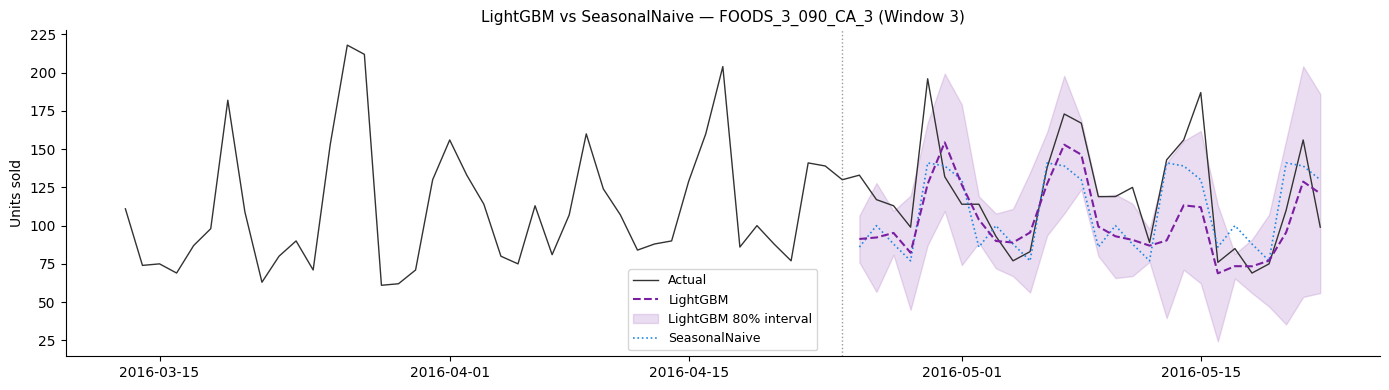

In [8]:
# Compare LightGBM vs SeasonalNaive on a single series
sample_uid = top_series[0]
sample_cut = ml_micro["cutoff"].unique()[-1]

actuals   = panel[panel["unique_id"] == sample_uid].set_index("ds")["y"]
plot_start = sample_cut - pd.Timedelta(days=42)

lgbm_fcast = ml_micro[
    (ml_micro["unique_id"] == sample_uid) &
    (ml_micro["cutoff"]    == sample_cut)
].set_index("ds")

# Load micro baselines for SeasonalNaive comparison
try:
    baseline_micro_path = ARTIFACT_DIR / "04_baseline_micro_forecasts.parquet"
    baseline_micro = pd.read_parquet(baseline_micro_path)
    snaive_fcast = baseline_micro[
        (baseline_micro["unique_id"] == sample_uid) &
        (baseline_micro["cutoff"]    == sample_cut) &
        (baseline_micro["model"]     == "SeasonalNaive")
    ].set_index("ds")
    has_baseline = True
except Exception:
    has_baseline = False

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(actuals[actuals.index >= plot_start].index,
        actuals[actuals.index >= plot_start].values,
        color="#333", linewidth=1.0, label="Actual", zorder=3)

ax.plot(lgbm_fcast.index, lgbm_fcast["y_hat"],
        color="#7B1FA2", linewidth=1.5, linestyle="--", label="LightGBM", zorder=4)
ax.fill_between(lgbm_fcast.index, lgbm_fcast["lo_80"], lgbm_fcast["hi_80"],
                alpha=0.15, color="#7B1FA2", label="LightGBM 80% interval")

if has_baseline and len(snaive_fcast) > 0:
    ax.plot(snaive_fcast.index, snaive_fcast["y_hat"],
            color="#1E88E5", linewidth=1.2, linestyle=":", label="SeasonalNaive", zorder=3)

ax.axvline(sample_cut, color="#999", linestyle=":", linewidth=1)
ax.set_title(f"LightGBM vs SeasonalNaive — {sample_uid} (Window 3)", fontsize=11)
ax.set_ylabel("Units sold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Expected output:** LightGBM forecast with shaded 80% interval alongside SeasonalNaive. The interval width communicates model confidence — compare it to the SeasonalNaive line visually.

---
## 5.9 — Score the Micro ML Forecasts
**[Code With Me — 1 line]**

> **Instructor note (2 min):** Students validate and score the micro results. One fill-in: the `validate_forecast` call. The point is to make schema validation a reflex — run it every time before scoring.

In [9]:
# Validate schema before scoring
ml_micro_validated = validate_forecast(ml_micro, artifact_name="05_ml_micro")  # __FILL_IN__: validate ml_micro

ml_micro_scores = score_forecasts(
    ml_micro_validated,
    subset_name=f"micro_{MICRO_SUBSET_N}",
)

wmape_row  = ml_micro_scores[ml_micro_scores["metric"] == "wMAPE"].iloc[0]
iscore_row = ml_micro_scores[ml_micro_scores["metric"] == "IntervalScore_80"].iloc[0]
bias_row   = ml_micro_scores[ml_micro_scores["metric"] == "Bias"].iloc[0]

print(f"LightGBM on micro subset ({MICRO_SUBSET_N} series):")
print(f"  wMAPE          : {wmape_row['score']:.4f}")
print(f"  Interval Score : {iscore_row['score']:.4f}")
print(f"  Bias           : {bias_row['score']:+.4f}  (+ = over-forecast, - = under-forecast)")

LightGBM on micro subset (50 series):
  wMAPE          : 0.2751
  Interval Score : 57.6758
  Bias           : +0.0425  (+ = over-forecast, - = under-forecast)


---
## 5.9b — Feature Engineering Impact: Micro vs Full Panel
**[Watch Only]**

> **Instructor note (3 min):** Three rows, two lessons.
> Row 1 (micro, rich): the live result from 5.6 — likely shows a small negative or near-zero delta. This is sampling noise on 50 series.
> Rows 2-3 (full panel, baseline vs rich): the precomputed apples-to-apples comparison on 1,000 series.
> The contrast between row 1 and row 3 IS the lesson: rich features appear to make things worse on the micro subset, and better on the full panel.
> Say this explicitly: "If you had only looked at 50 series, you would have thrown away a feature set that improves accuracy by 1.5% at scale. Small subsets lie."
>
> Secondary lesson: feature engineering (+1.5%) beat 100 Optuna trials (~0.5%). That ordering holds on almost every real retail dataset.

In [10]:
%%time
# 5.9b — Feature engineering impact: micro subset (live) vs full panel (precomputed)
# Runs a quick baseline CV on micro to complete the 2x2 comparison table.

# ── Baseline CV on micro (fast, ~15 sec) ─────────────────────────────────────
cv_ml_base_micro = mlf.cross_validation(
    df=micro,
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=STEP_SIZE,
    refit=True if USE_INTERVALS else REFIT,
    prediction_intervals=PredictionIntervals(n_windows=N_WINDOWS, h=HORIZON) if USE_INTERVALS else None,
    level=[80] if USE_INTERVALS else None,
)
ml_base_micro = reshape_mlforecast_cv(cv_ml_base_micro, model_col="LGBMRegressor", stage="ml")
scores_base_micro = score_forecasts(
    validate_forecast(ml_base_micro, artifact_name="05_ml_base_micro"),
    subset_name=f"micro_{MICRO_SUBSET_N}",
)
wmape_micro_base = scores_base_micro[scores_base_micro["metric"] == "wMAPE"].iloc[0]["score"]
bias_micro_base  = scores_base_micro[scores_base_micro["metric"] == "Bias"].iloc[0]["score"]

wmape_micro_rich = wmape_row["score"]   # from 5.9 — mlf_rich on micro
bias_micro_rich  = bias_row["score"]

# ── Full-panel precomputed ────────────────────────────────────────────────────
try:
    ml_full_base = load_checkpoint("05_ml_forecasts")
    ml_full_rich = load_checkpoint("05_ml_rich_forecasts")

    scores_full_base = score_forecasts(ml_full_base, subset_name=f"workshop_{WORKSHOP_SUBSET_N}")
    scores_full_rich = score_forecasts(ml_full_rich, subset_name=f"workshop_{WORKSHOP_SUBSET_N}")

    wmape_full_base = scores_full_base[scores_full_base["metric"] == "wMAPE"].iloc[0]["score"]
    bias_full_base  = scores_full_base[scores_full_base["metric"] == "Bias"].iloc[0]["score"]
    wmape_full_rich = scores_full_rich[scores_full_rich["metric"] == "wMAPE"].iloc[0]["score"]
    bias_full_rich  = scores_full_rich[scores_full_rich["metric"] == "Bias"].iloc[0]["score"]

    imp_micro = (wmape_micro_base - wmape_micro_rich) / wmape_micro_base * 100
    imp_full  = (wmape_full_base  - wmape_full_rich)  / wmape_full_base  * 100

    W = 28
    print(f"Feature Engineering Impact ({N_WINDOWS} CV windows):")
    print(f"  {'Scale':<{W}} {'Features':<22} {'wMAPE':>8}  {'Bias':>8}  {'Improvement':>12}")
    print(f"  {'-'*86}")
    print(f"  {f'Micro ({MICRO_SUBSET_N} series — live)':<{W}} {'Baseline (5.5)':<22} {wmape_micro_base:>8.4f}  {bias_micro_base:>+8.4f}  {'—':>12}")
    print(f"  {f'Micro ({MICRO_SUBSET_N} series — live)':<{W}} {'Rich (5.5b)':<22} {wmape_micro_rich:>8.4f}  {bias_micro_rich:>+8.4f}  {imp_micro:>+11.1f}%")
    print(f"  {'-'*86}")
    print(f"  {f'Full panel ({WORKSHOP_SUBSET_N} series)':<{W}} {'Baseline (5.5)':<22} {wmape_full_base:>8.4f}  {bias_full_base:>+8.4f}  {'—':>12}")
    print(f"  {f'Full panel ({WORKSHOP_SUBSET_N} series)':<{W}} {'Rich (5.5b)':<22} {wmape_full_rich:>8.4f}  {bias_full_rich:>+8.4f}  {imp_full:>+11.1f}%")
    print()
    print("Key lesson: micro result is noise — never make feature engineering decisions on small subsets.")
except FileNotFoundError as e:
    print(f"Artifact not found: {e}")
    print("Run: python src/build_offline_artifacts.py --stages ml ml_rich")


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 05_ml_forecasts
    File     : 05_ml_forecasts.parquet
    Rows     : 84,000


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 05_ml_rich_forecasts
    File     : 05_ml_rich_forecasts.parquet
    Rows     : 84,000

Feature Engineering Impact (3 CV windows):
  Scale                        Features                  wMAPE      Bias   Improvement
  --------------------------------------------------------------------------------------
  Micro (50 series — live)     Baseline (5.5)           0.2746   +0.0289             —
  Micro (50 series — live)     Rich (5.5b)              0.2751   +0.0425         -0.2%
  --------------------------------------------------------------------------------------
  Full panel (1000 series)     Baseline (5.5)           0.4652   +0.0180             —
  Full panel (1000 series)     Rich (5.5b)              0.4604   +0.0202         +1.0%

Key lesson: micro result is noise — never make feature engineering decisions on sma



> **Instructor note:** Do not read the micro score as final. The micro subset is the top-50 by volume — the easiest 50 to forecast. The full-subset score will be higher (worse). This is a known selection bias.

---
## 5.10 — Load Full-Subset ML Forecasts and Update Leaderboard
**[Watch Only]**

> **Instructor note (2 min):** Load the precomputed full-subset ML artifact, score it, and compare against the baseline floor. This is the first real leaderboard update — does LightGBM beat AutoETS?

In [13]:
# 🔴 RED PATH (standard) — load precomputed full-subset ML forecasts
ml_full = load_checkpoint("05_ml_rich_forecasts")

ml_full_scores = score_forecasts(
    ml_full,
    subset_name=f"workshop_{WORKSHOP_SUBSET_N}",
)

# Load baseline scores for comparison
baseline_full = load_checkpoint("04_baseline_forecasts")
baseline_scores = score_forecasts(
    baseline_full,
    subset_name=f"workshop_{WORKSHOP_SUBSET_N}",
)

# Combine into updated leaderboard
from src.evaluation import build_leaderboard
leaderboard_5 = build_leaderboard([baseline_scores, ml_full_scores])

print("Updated leaderboard (wMAPE):")
wmape_lb = leaderboard_5[["model", "wMAPE", "Bias"]].dropna().sort_values("wMAPE") if "wMAPE" in leaderboard_5.columns else leaderboard_5
print(wmape_lb.to_string(index=False))


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 05_ml_rich_forecasts
    File     : 05_ml_rich_forecasts.parquet
    Rows     : 84,000


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 04_baseline_forecasts
    File     : 04_baseline_forecasts.parquet
    Rows     : 336,000

Updated leaderboard (wMAPE):
          model    wMAPE      Bias
  LightGBM-Rich 0.460392  0.020181
        AutoETS 0.474567  0.000437
Chronos-t5-mini 0.492306 -0.169574
  SeasonalNaive 0.558018 -0.025829
          Naive 0.665166  0.169000


**Expected output:**
```
Updated leaderboard (wMAPE):
          model    wMAPE
       LightGBM   0.XXXX
        AutoETS   0.XXXX
  SeasonalNaive   0.XXXX
Chronos-t5-mini   0.XXXX
          Naive   0.XXXX
```

> **Instructor note:** LightGBM should beat AutoETS on wMAPE for most M5 subsets. If it does not, the feature pipeline needs review. The gap between them is the quantified value of the ML pipeline.

---
## 5.11 — Save the Micro ML Artifact
**[Watch Only]**

> **Instructor note (30 sec):** Save the micro results for optional take-home analysis. The full-subset artifact is already loaded.

In [14]:
micro_ml_path = ARTIFACT_DIR / "05_ml_micro_forecasts.parquet"
ml_micro_validated.to_parquet(micro_ml_path, index=False)
print(f"  ✓ Micro ML artifact saved : {micro_ml_path.name} ({len(ml_micro_validated):,} rows)")
print(f"  ✓ Full ML artifact loaded : 05_ml_forecasts.parquet ({len(ml_full):,} rows)")

  ✓ Micro ML artifact saved : 05_ml_micro_forecasts.parquet (4,200 rows)
  ✓ Full ML artifact loaded : 05_ml_forecasts.parquet (84,000 rows)


---
## 5.12 — The Enterprise Cliff
**[Watch Only]**

> **Instructor note (2 min):** This is the authority hook. Say the first paragraph slowly — it is the line that differentiates practitioners from notebook runners.

Adding lags in a notebook is a one-liner. **Orchestrating a scalable feature pipeline across 100,000 SKUs is where enterprise forecasting systems diverge from standalone scripts.**

What we simplified:

**Lag computation at scale:**  
MLForecast computes lags on the fly during CV. In production, lags are computed once, stored in a feature store, versioned, and served to the model at inference time. Late-arriving data invalidates precomputed lags — your pipeline needs a backfill strategy.

**Conformal intervals at scale:**  
`PredictionIntervals` uses held-out cross-validation windows to calibrate the conformal bounds — the calibration data is separate from the training data. That said, the calibration set is still drawn from the same historical distribution. On series with sudden trend shifts or promotional events, the historical error distribution will not match future errors, and the intervals will undercover.

**The ROI question:**  
LightGBM beat AutoETS by some margin on wMAPE. The question your CFO asks is: how many basis points of safety stock reduction does that margin translate to? If the answer is less than the infrastructure cost of maintaining a feature store, AutoETS is the right production choice.

---

> **Instructor note — transition:** "We have a working ML pipeline and a leaderboard with 5 models. One more to add — a global neural model."
>
> Open `instructor_notebooks/06_deep_learning.ipynb`.